# Bootstrapped Feature Selection → Model Development & Evaluation (Nested CV)

This notebook implements a workflow where **feature selection is performed via bootstrapping** to identify a **stable feature set**, and then **model development + evaluation** is carried out using **nested cross-validation (CV)**.

## What this notebook does

* Runs **bootstrapped feature selection** to estimate **feature stability** (e.g., selection frequency) and produce a **final stable feature set**.
* Uses the **final stable feature set** to proceed into:

  * **model development / hyperparameter tuning** (inner CV),
  * **final training** on each outer-train split,
  * **evaluation** on each outer-test split.
* Reports **nested-CV performance** using a **fixed, stability-selected feature set** (rather than fold-specific feature sets).

## Key idea

Feature selection is done using **bootstrapping to measure stability**, producing a single **stable feature set**. That stable feature set is then treated as the input feature space for the **nested CV model development and evaluation** workflow, keeping the modeling evaluation unbiased while avoiding re-selecting features separately in each outer fold.


In [1]:
import ai_framework.ml_data_preprocessing as mdp
import ai_framework.ml_feature_selection as mfs
import ai_framework.ml_tuning_calib_interpret as mtci
import ai_framework.post_analysis as post
import ai_framework.utils as ut

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer



## Breast Cancer Wisconsin (Diagnostic) Dataset

The Breast Cancer Wisconsin Diagnostic dataset contains measurements computed from digitized images of fine needle aspirates (FNA) of breast masses. These measurements describe characteristics of the cell nuclei present in each image.

### Dataset Characteristics

- **Number of instances:** 569
- **Number of attributes:** 30 numeric predictive features
- **Target variable:** Diagnosis class
- **Missing values:** None

### Class Labels

| Class | Description |
|---|---|
| `WDBC-Malignant` | Malignant tumor |
| `WDBC-Benign` | Benign tumor |

### Class Distribution

| Class | Number of instances |
|---|---:|
| Malignant | 212 |
| Benign | 357 |

### Feature Information

The dataset is based on 10 core measurements computed from each cell nucleus image:

| Feature | Description |
|---|---|
| `radius` | Mean distance from the center to points on the perimeter |
| `texture` | Standard deviation of gray-scale values |
| `perimeter` | Perimeter of the nucleus |
| `area` | Area of the nucleus |
| `smoothness` | Local variation in radius lengths |
| `compactness` | Perimeter² / area − 1.0 |
| `concavity` | Severity of concave portions of the contour |
| `concave points` | Number of concave portions of the contour |
| `symmetry` | Symmetry of the nucleus |
| `fractal dimension` | “Coastline approximation” − 1 |

For each of these 10 measurements, the **mean**, **standard error**, and **worst** value were calculated. The “worst” value refers to the largest or most extreme value, calculated as the mean of the three largest values.

This results in a total of **30 numeric features**.

For example:

- Field 0: Mean Radius
- Field 10: Radius Standard Error
- Field 20: Worst Radius

### Source and Background

This dataset is a copy of the UCI Machine Learning Repository’s Breast Cancer Wisconsin Diagnostic dataset.

Dataset source:  
[https://goo.gl/U2Uwz2](https://goo.gl/U2Uwz2)

The dataset was created in **November 1995** by:

- Dr. William H. Wolberg
- W. Nick Street
- Olvi L. Mangasarian

The dataset was donated by **Nick Street**.

### Methodological Notes

The separating plane described for this dataset was obtained using the **Multisurface Method-Tree (MSM-T)**, a classification method that uses linear programming to construct a decision tree.

Relevant features were selected using an exhaustive search over combinations of 1–4 features and 1–3 separating planes.

### References

K. P. Bennett (1992).  
“Decision Tree Construction Via Linear Programming.”  
*Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society*, pp. 97–101.

K. P. Bennett and O. L. Mangasarian (1992).  
“Robust Linear Programming Discrimination of Two Linearly Inseparable Sets.”  
*Optimization Methods and Software*, 1, pp. 23–34.

### Additional Availability

This database is also available through the University of Wisconsin CS FTP server:

`ftp.cs.wisc.edu`

Path:

`math-prog/cpo-dataset/machine-learn/WDBC/`

### Prepare data

In [ ]:
# from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Generate train and validation sets
train_df, validation_df = mtci.prepare_dataset(
    X=data.data,
    y=data.target,
    feature_names=data["feature_names"],
    target_name="target",
    validation_size=0.2,
    random_state=42,
)


### Save validation data

In [ ]:
# -----------------------------------------------------------------------------------------------------------------------------------
# Separate the training DataFrame into input features and target.
X_validation = validation_df.drop(columns=['target'])
y_validation = validation_df['target']

# Save data
path = 'tutorial/run_1/data'
prefix = 'validation_dataset'
ut.save_prepared_dataset_bundle(
    output_dir=path,
    X_raw=X_validation.to_numpy(), # X
    y=y_validation.to_numpy(), # y
    feature_names=X_validation.columns.to_list(), # feature_names
    prefix=prefix,
)

### Save and load training data

In [ ]:
# Separate the training DataFrame into input features and target.
X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

# Save data
path = 'tutorial/run_1/breast_cancer'
prefix = 'all_features'
ut.save_prepared_dataset_bundle(
    output_dir=path,
    X_raw=X_train.to_numpy(), # X
    y=y_train.to_numpy(), #y
    feature_names=X_train.columns.to_list(), #feature_names
    prefix=prefix,
)


# Load bundle dataset
path = 'tutorial/run_1/breast_cancer'
prefix = 'all_features'
bundle = ut.load_prepared_dataset_bundle(output_dir=path, prefix=prefix, require=None,)

In [3]:
df = pd.DataFrame(bundle['X_raw'],  
                  columns=bundle['feature_names'])
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,10.320000,16.350000,65.309998,324.899994,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.250000,21.770000,71.120003,384.899994,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
1,20.180000,19.540001,133.800003,1250.000000,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.030001,25.070000,146.000000,1479.000000,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
2,10.660000,15.150000,67.489998,349.600006,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,11.540000,19.200001,73.199997,408.299988,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
3,13.560000,13.900000,88.589996,561.299988,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,14.980000,17.129999,101.099998,686.599976,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
4,11.370000,18.889999,72.169998,396.000000,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,12.360000,26.139999,79.290001,459.299988,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,15.280000,22.410000,98.919998,710.599976,0.09057,0.10520,0.05375,0.032630,0.1727,0.06317,...,17.799999,28.030001,113.800003,973.099976,0.1301,0.32990,0.36300,0.12260,0.3175,0.09772
451,19.530001,18.900000,129.500000,1217.000000,0.11500,0.16420,0.21970,0.106200,0.1792,0.06552,...,25.930000,26.240000,171.100006,2053.000000,0.1495,0.41160,0.61210,0.19800,0.2968,0.09929
452,15.460000,23.950001,103.800003,731.299988,0.11830,0.18700,0.20300,0.085200,0.1807,0.07083,...,17.110001,36.330002,117.699997,909.400024,0.1732,0.49670,0.59110,0.21630,0.3013,0.10670
453,17.049999,19.080000,113.400002,895.000000,0.11410,0.15720,0.19100,0.109000,0.2131,0.06325,...,19.590000,24.889999,133.500000,1189.000000,0.1703,0.39340,0.50180,0.25430,0.3109,0.09061


In [4]:
df_v2, tab_meta = mdp.encode_categorical_and_ordinal( df=df ,
                                                 cat_cols=[], # explicitly mark categorical columns (none here)
                                                ord_cols=[], # explicitly mark ordinal columns (none here)
                                                low_card_max=3,
                                                ordinal_card_max=10,
                                                drop_first=True,
                                                return_metadata =True)
df_v2

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,10.320000,16.350000,65.309998,324.899994,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.250000,21.770000,71.120003,384.899994,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
1,20.180000,19.540001,133.800003,1250.000000,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.030001,25.070000,146.000000,1479.000000,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
2,10.660000,15.150000,67.489998,349.600006,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,11.540000,19.200001,73.199997,408.299988,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
3,13.560000,13.900000,88.589996,561.299988,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,14.980000,17.129999,101.099998,686.599976,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
4,11.370000,18.889999,72.169998,396.000000,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,12.360000,26.139999,79.290001,459.299988,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,15.280000,22.410000,98.919998,710.599976,0.09057,0.10520,0.05375,0.032630,0.1727,0.06317,...,17.799999,28.030001,113.800003,973.099976,0.1301,0.32990,0.36300,0.12260,0.3175,0.09772
451,19.530001,18.900000,129.500000,1217.000000,0.11500,0.16420,0.21970,0.106200,0.1792,0.06552,...,25.930000,26.240000,171.100006,2053.000000,0.1495,0.41160,0.61210,0.19800,0.2968,0.09929
452,15.460000,23.950001,103.800003,731.299988,0.11830,0.18700,0.20300,0.085200,0.1807,0.07083,...,17.110001,36.330002,117.699997,909.400024,0.1732,0.49670,0.59110,0.21630,0.3013,0.10670
453,17.049999,19.080000,113.400002,895.000000,0.11410,0.15720,0.19100,0.109000,0.2131,0.06325,...,19.590000,24.889999,133.500000,1189.000000,0.1703,0.39340,0.50180,0.25430,0.3109,0.09061


In [5]:
bundle['X_raw'] = df_v2.to_numpy()
bundle['feature_names'] = list(df_v2.columns)

### Explore data missingness and run data preprocessing

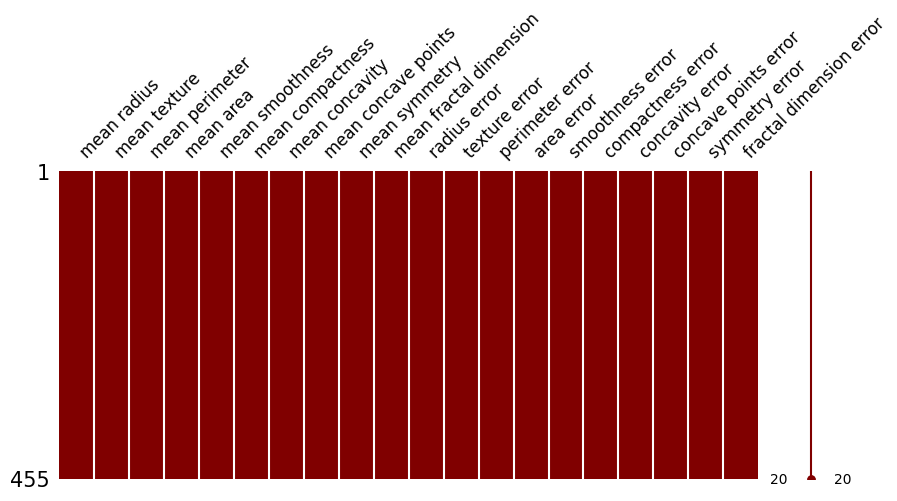

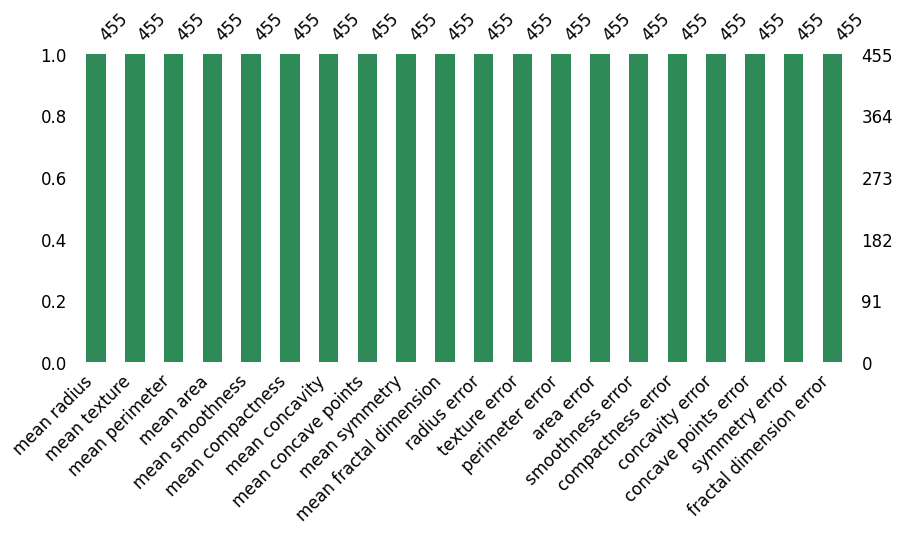

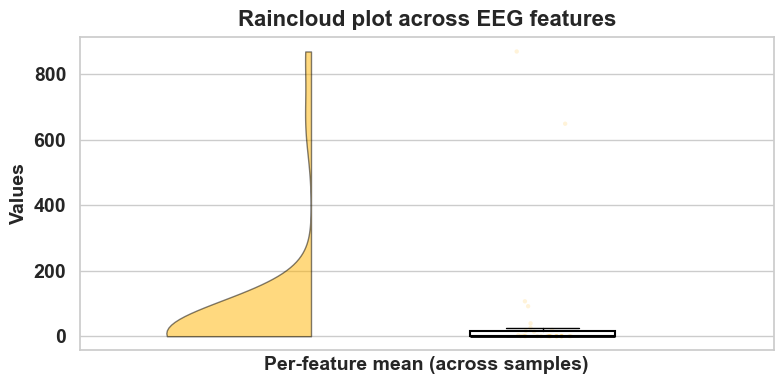

In [6]:

# Quick overview per epoch/feature, first 20 features
mdp.visualize_missingness(
    X_raw=bundle['X_raw'],
    feature_names=bundle['feature_names'],
    kind="matrix",
    max_features=20,
    figsize=(10, 4),
    fontsize=12,
    color="maroon",
    sort="ascending",
)

# Non-missing counts per feature, different style
mdp.visualize_missingness(
    X_raw=bundle['X_raw'],
    feature_names=bundle['feature_names'],
    kind="bar",
    max_features=20,
    figsize=(10, 4),
    fontsize=12,
    color="seagreen",
    sort="ascending",
)

summary_raw = mdp.summarize_feature_matrix(bundle['X_raw'], bundle['feature_names'])
mdp.plot_feature_stat_raincloud(summary_raw, stat="mean",  figsize=(8, 4), font_size=14, violin_half="right" )



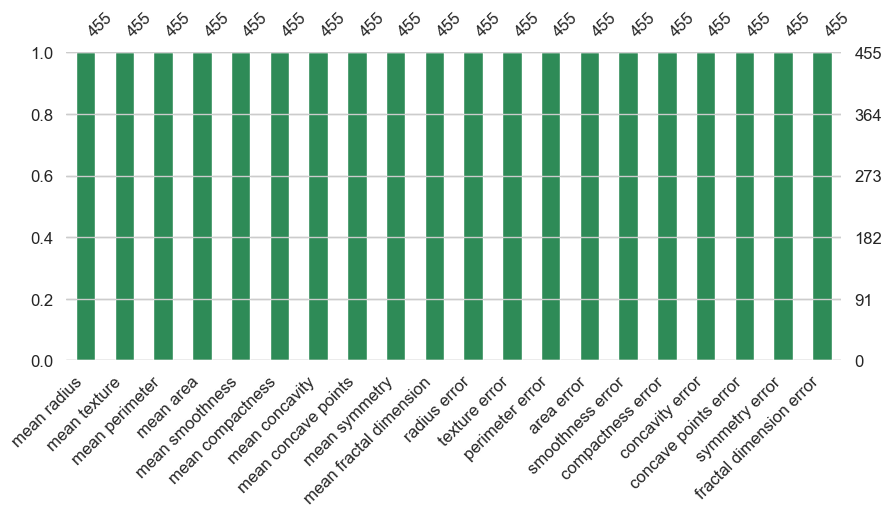

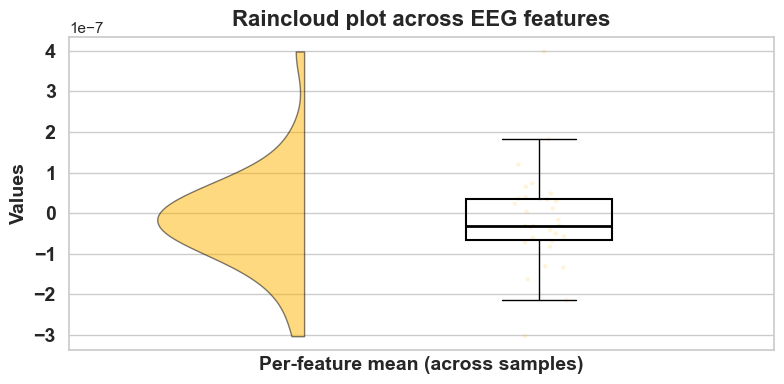

In [39]:


# Run data preprocessing
bundle = mdp.data_preprocessing_pipeline(
    bundle=bundle,
    lower_q = 0.05,
    upper_q = 0.95,
    impute_strategy = "median",
    preproc_key = "preproc",
    meta=None, # use tab_meta if you have additional metadata such as Age and Gender
)

# After scaling: re-check
# Quick overview per epoch/feature, first 20 features
# Non-missing counts per feature, different style
mdp.visualize_missingness(
    X_raw=bundle['X_scaled'],
    feature_names=bundle['feature_names'],
    kind="bar",
    max_features=20,
    figsize=(10, 4),
    fontsize=12,
    color="seagreen",
    sort="ascending",
)

summary_scaled = mdp.summarize_feature_matrix(bundle['X_scaled'], bundle['feature_names'])
mdp.plot_feature_stat_raincloud(summary_scaled, stat="mean",  figsize=(8, 4), font_size=14, violin_half="right" )




### Save/Load Preprocessed EEG Features (Winsorization, Imputation, Standard Scaling, and Fitted Preprocessors)

In [40]:
# All features
# -----------------------------------------------------------------------------------------------------------------------------------
path = 'tutorial/run_1/breast_cancer'
prefix = 'all_features_preproc'
mtci.save_all_results( output_dir=path, all_results = bundle,prefix=prefix,compress=True,)
bundle = mtci.load_all_results(output_dir=path,prefix=prefix,compress=True)
# -----------------------------------------------------------------------------------------------------------------------------------



✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\all_features_preproc.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\all_features_preproc.pkl.gz


# Feature Selection Pipeline

This notebook uses a **two-stage permutation-based feature ranking and selection pipeline**.

The pipeline is designed around two complementary stages:

1. **Exploration stage**
   - A relatively large set of top-ranked features is retained after the first stage.

2. **Refinement stage**
   - The second stage reranks the surviving features using the same core ranking procedure, but with more repeated feature exposure.


## Why `target_feature_appearances` matters

One of the most important stability parameters in this pipeline is `target_feature_appearances`.

- increasing `target_feature_appearances` increases the number of runs and gives each feature more repeated exposure
- increasing `subset_size` reduces the number of runs because more features are evaluated in each sampled subset
- increasing the number of incoming features increases the number of runs needed to maintain the same average exposure per feature

This makes `target_feature_appearances` one of the key parameters controlling the tradeoff between ranking stability and computational cost.

In practice, this parameter often has a strong influence on how stable the top 10 or top 20 features become.

The number of subset-sampling runs is computed as:

$$
n_{\mathrm{runs}} = \left\lceil \frac{\mathrm{target\_feature\_appearances} \times n_{\mathrm{features}}}{\mathrm{subset\_size}} \right\rceil

$$


## Why subset size matters

The `subset_sizes` parameter controls how many features are evaluated together in each sampled model.

Smaller subsets can sometimes make feature contributions easier to separate, but they require more subset-sampling runs to give every feature enough exposure. Larger subsets are usually more computationally efficient because more features are evaluated in each run.

A useful practical tradeoff is:

- **smaller subsets**: potentially sharper competition, but more expensive
- **larger subsets**: more efficient, often still effective when rankings are aggregated properly


In [9]:
%%time

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

RANK_SELECT_PIPELINE_CFG = {
    "defaults": {
        "task_type": "classification",       # "classification" or "regression"
        "scoring": "roc_auc",                # metric used by permutation_importance to score validation performance
        "n_splits": 5,                       # number of CV folds used in the selected splitter

        # fallback values used only if a stage does not override them
        "n_repeats": 25,                     # number of permutation shuffles per feature inside permutation_importance
        "target_feature_appearances": 5,    # target number of times each feature should appear across sampled subsets
        
        "random_state": 42,                  # base random seed for reproducibility
        "ranking_metric": "auto",            # final ranking rule: auto, mean_normalized_rank, or mean_importance
        "group_mode": False,                 # if True, repeatedly sample one row per group before ranking
        "group_iterations": 5,              # number of one-row-per-group resampling iterations when group_mode=True

        # row subsampling: for each feature-subset run, sample rows before CV
        # unused rows are discarded; CV + permutation importance use only sampled rows
        "row_subsampling": {
            "enabled": True,                 # if True, sample rows before CV for each feature-subset run
            "train_fraction": 0.8,           # fraction of rows kept for ranking in each run
            "stratify": True,                # preserve class balance when sampling rows for classification. Ignored for regression; use False for clarity
        },
    },
    "models": {
        "logistic_regression": LogisticRegression(max_iter=50000),          # model to rank features with
        "xgboost": XGBClassifier(objective= 'binary:logistic', eval_metric="logloss", n_estimators=100, max_depth=4, random_state=42),  # second model to rank features with
    },
    "stages": [
        {
            "name": "coarse_rank_select",    # stage label used in output/history
            "top_k": 25,                     # number of highest-ranked features to keep after this stage
            "subset_sizes": [15],         # feature subset sizes tested during ranking in this stage
             # stage-specific override
            "n_repeats": 25,
            "target_feature_appearances": 50,
        },
        {
            "name": "final_rank_select",     # second-stage label used in output/history
            "top_k": 15,                      # number of highest-ranked features to keep after this stage
            "subset_sizes": [15],         # feature subset sizes tested during ranking in this stage
             # stage-specific override
            "n_repeats": 25,
            "target_feature_appearances": 50,
        },

    ],
}
# n_runs = ceil((target_feature_appearances * n_features) / subset_size)



final_features = mfs.balanced_permutation_rank_select_pipeline(
    X=bundle['X_scaled'],
    y=bundle['y'],
    groups=None,
    feature_names=bundle['feature_names'],
    cfg=RANK_SELECT_PIPELINE_CFG, 
)





Feature selection stage=coarse_rank_select | model=logistic_regression:   0%|          | 0/1 [00:00<?, ?subset…

logistic_regression | subset=15:   0%|          | 0/100 [00:00<?, ?run/s]

Feature selection stage=final_rank_select | model=logistic_regression:   0%|          | 0/1 [00:00<?, ?subset/…

logistic_regression | subset=15:   0%|          | 0/84 [00:00<?, ?run/s]

Feature selection stage=coarse_rank_select | model=xgboost:   0%|          | 0/1 [00:00<?, ?subset/s]

xgboost | subset=15:   0%|          | 0/100 [00:00<?, ?run/s]

Feature selection stage=final_rank_select | model=xgboost:   0%|          | 0/1 [00:00<?, ?subset/s]

xgboost | subset=15:   0%|          | 0/84 [00:00<?, ?run/s]

CPU times: total: 21min 54s
Wall time: 2min 38s


### Save and load final features

In [10]:
# Load data and select the number of features you want
path = 'tutorial/run_1/breast_cancer'

# Save output
mtci.save_all_results(output_dir=path, all_results=final_features, prefix='final_features', compress=True)

# Load output
all_results = mtci.load_all_results(output_dir=path, prefix='final_features', compress=True) # Initialize dict to track ML results
final_features = mtci.load_all_results(output_dir=path, prefix='final_features', compress=True) # Stores final features for each model



✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz


## Config file

In [11]:
# ---------------------------------------------------------------------
# 1. Config: models, CV knobs, Optuna knobs, metric
# ---------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


# Select top k features
top_k = 5
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]

config = {
    "cv": {
        "num_trials": 5,
        "n_outer_splits": 5,
        "n_inner_splits": 4,
    },
    "optuna": {
        "n_inner_trials": 300,
        "direction": "maximize",
         "n_jobs": 1,
    },
    "metric": {
        "scoring": "roc_auc",   #  "average_precision" | "roc_auc"
        "name": "AUROC",           # "AUPRC"  | "AUROC"
    },
    "models": {
        "logistic_regression": {
            "enabled": True, # flip to False if you don't want it to run
            "feature_names": lr_top, 
            "feature_strict": True,
            "n_features": None,

            "estimator_cls": LogisticRegression,
            "params": lambda trial: {
                "solver": "saga",
                "random_state": 42,
                "l1_ratio": (
                    trial.suggest_float("l1_ratio", 0.0, 1.0)
                    if trial is not None else 0.0
                ),
                "C": (
                    trial.suggest_float("C", 1e-1, 50.0, log=True)
                    if trial is not None else None
                ),
                "max_iter": (
                    trial.suggest_int("max_iter", 150000, 350000)
                    if trial is not None else None
                ),
                # "class_weight": (
                #     trial.suggest_categorical("class_weight", [None, "balanced"])
                #     if trial is not None else None
                # ),
            },
        },

        # Random Forest model
        "random_forest": {
            "enabled": False,   # flip to False if you don't want it to run
            "estimator_cls": RandomForestClassifier,
            "params": lambda trial: {
                "n_jobs": -1,
                "random_state": 42,

                "n_estimators": (
                    trial.suggest_int("n_estimators", 50, 500)
                    if trial is not None else None
                ),
                "ccp_alpha": (
                    trial.suggest_float("ccp_alpha", 0.0, 0.1)
                    if trial is not None else None
                ),
                "class_weight": (
                    trial.suggest_categorical(
                        "class_weight",
                        [None, "balanced", "balanced_subsample"],
                    )
                    if trial is not None else None
                ),
            },
        },

        # XGBoost model
        "xgboost": {
            "enabled": True, # flip to False if you don't want it to run
            "estimator_cls": XGBClassifier,
            "feature_names": xgb_top,
            "feature_strict": True,
            "n_features": None,
            "params": lambda trial: {
                # ---- fixed / always-on params ----
                "objective": "binary:logistic",
                "eval_metric": "auc",   # "aucpr" or "auc"
                "random_state": 42,
                "n_jobs": -1,
                "verbosity": 0,
                "tree_method": "hist",    # CPU-fast; use "gpu_hist" if you have a CUDA GPU

                # ---- tunable params (else None like your other models) ----
                #"n_estimators": 500,
                "n_estimators": (
                    trial.suggest_int("n_estimators", 200, 600)
                    if trial is not None else None
                ),
                "learning_rate": (
                    trial.suggest_float("learning_rate", 1e-2, 0.3, log=True)
                    if trial is not None else None
                ),

                "max_depth": (
                    trial.suggest_int("max_depth", 2, 6)
                    if trial is not None else None
                ),
                
                "min_child_weight": (
                    trial.suggest_float("min_child_weight", 5.0, 50.0, log=True)
                    if trial is not None else None
                ),
                ## stochasticity
                "subsample": (
                    trial.suggest_float("subsample", 0.5, 1.0)
                    if trial is not None else None
                ),
                "colsample_bytree": (
                    trial.suggest_float("colsample_bytree", 0.5, 1.0)
                    if trial is not None else None
                ),

                ## regularization
                # "gamma": (
                #     trial.suggest_float("gamma", 1, 10.0, log=True)
                #     if trial is not None else None
                # ),
                "reg_alpha": (
                    trial.suggest_float("reg_alpha", 0.01, 10.0, log=True)
                    if trial is not None else None
                ),
                "reg_lambda": (
                    trial.suggest_float("reg_lambda", 1, 20.0, log=True)
                    if trial is not None else None
                ),

                # ## Weight
                # "scale_pos_weight": (
                #     trial.suggest_float("scale_pos_weight", 1.0, 5.0, log=True)
                #     if trial is not None else None
                # ),

            },
        },

    },
}


### Summarize splits and label counts

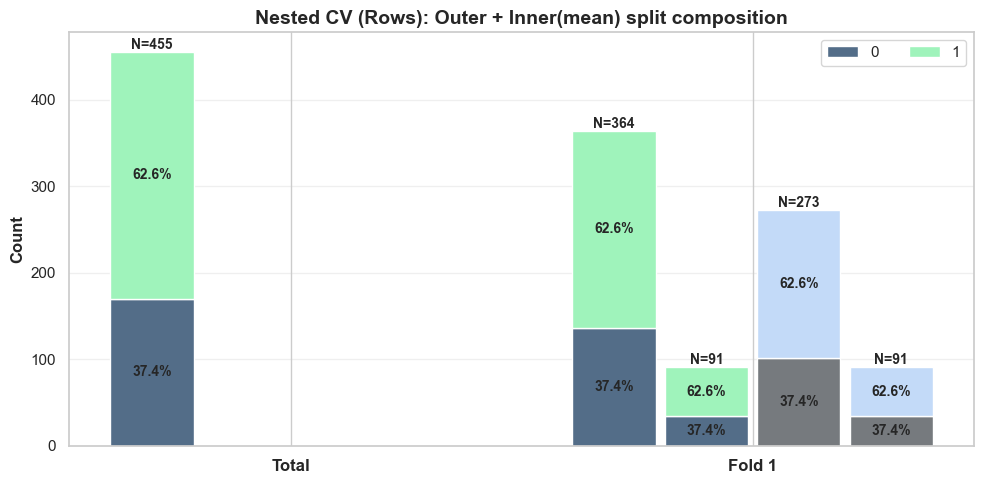

In [12]:
# ------------------------------------------------------------
# Summarize how nested CV splits your data WITHOUT training any models.
# ------------------------------------------------------------
X = final_features['final_by_model']['logistic_regression']['X']
y = final_features['y']
sizes = mtci.summarize_cv_split_sizes(
    X=X,            # feature matrix (rows = observations)
    y=y,                     # row-level labels (assumed constant within each patient)
    cfg=config,                        # must contain cfg["cv"]["n_outer_splits"], cfg["cv"]["n_inner_splits"]
    groups=None,           # patient IDs per row (same length as y)
    model_selection="StratifiedKFold",  # group-aware + stratified outer/inner splits
)


# ------------------------------------------------------------
# ROW-LEVEL plot (each row is an observation)
# Useful when you care about total number of ROWS used in each split.
# ------------------------------------------------------------
mtci.plot_outer_counts_and_class_percents(
    sizes,                         # output from summarize_cv_split_sizes(...)
    figsize=(10, 5),               # figure size
    font_size=12,                  # overall font size for labels/annotations
    show_segment_percents=True,    # write % inside each stacked segment
    show_total_labels=True,        # write N=... above each bar
    legend_loc="best",             # legend placement
    outer_fold_color=["#536D88", "#9FF3BB"],  # colors for Total + OUTER bars (per class)
    inner_fold_color=["#767A7E", "#C3DAF8"], # colors for INNER(mean) bars (per class)
    class_names=['0', '1'],     # optional: e.g., ["Negative", "Positive"]
    count_level="rows",            # plot ROW counts (not unique patients)
    title=None,                    # optional: override title (else default is used)
    folds_show=1,                  # show only first 2 outer folds (Total is always shown)
)


## Run model training with nested-cv

In [ ]:
%%time
# ---------------------------------------------------------------------
# Example: run nested CV for all enabled models in config
# ---------------------------------------------------------------------
all_results = {}

for model_name, m_cfg in config["models"].items():
    if not m_cfg.get("enabled", False):
        continue

    print(f"\n>>> Running nested CV for model: {model_name}")
      
    model_results = mtci.run_nested_cv_for_model(
        model_name=model_name,
        model_data=final_features["final_by_model"][model_name],
        y=final_features["y"],
        cfg=config,
        groups=None,   # or shared groups array if you have one
        model_selection="StratifiedKFold",
    )
    all_results[model_name] = model_results




## Functions to save and load ML model and outputs

In [14]:

path = 'tutorial/run_1/breast_cancer'
prefix = 'feat_nestedcv'

# Save output
mtci.save_all_results(output_dir=path, all_results=all_results, prefix=prefix, compress=True)

# Load output
all_results = mtci.load_all_results(output_dir=path, prefix=prefix, compress=True)

✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\feat_nestedcv.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\feat_nestedcv.pkl.gz


## Calibration

Calibrate the **uncalibrated probability scores** produced during nested CV for each `(model, trial, outer_fold)`.

For every outer fold, we generate **out-of-fold (OOF)** probabilities on the outer-train split and fit the selected calibrators (e.g., **Platt**, **Beta**), then apply them to the stored outer-test scores. Calibration is configured via `calibration_config` and respects **per-model feature selection**.


In [15]:
# Calibrate probability outputs AFTER nested CV, using per-model feature slicing (same as training).

all_results = mtci.calibrate_nested_cv_results(
    all_results=all_results,                # nested-CV output dict: {model_name: [fold_dict, ...]} (mutated in-place)
    final_features=final_features,          # full dataset  (must contain X/y arrays + feature names for slicing)
    cfg=config,                             # your config with per-model feature selection + model params
    groups=None,                            # optional group ids key (only needed for StratifiedGroupKFold; e.g. "combined_groups")
    model_selection="StratifiedKFold",      # CV splitter used to generate OOF train probs for calibration
    n_splits=5,                             # K folds for the OOF cross_val_predict on each outer-train split
    calibration_methods=["platt","beta"],   # which calibrators to fit on OOF train probs ("platt", "beta", or both)
    train_probs_source = "refit",           #"oof" (cross-validated) or "refit" (final_model train scores)
)


c:\Users\neyot\anaconda3\envs\ML_main\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


### Plot calibration-sensitive metrics (Brier score loss and Log loss) as grouped bar charts across calibration methods, with Train vs Test bars showing mean ± SD over outer folds.

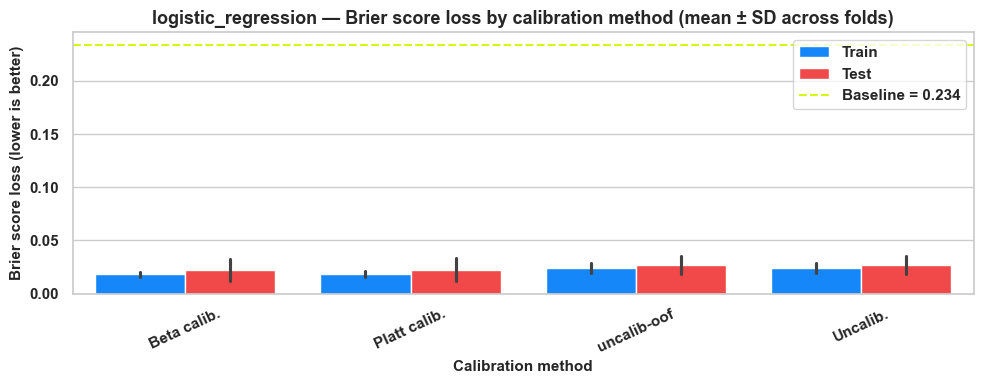

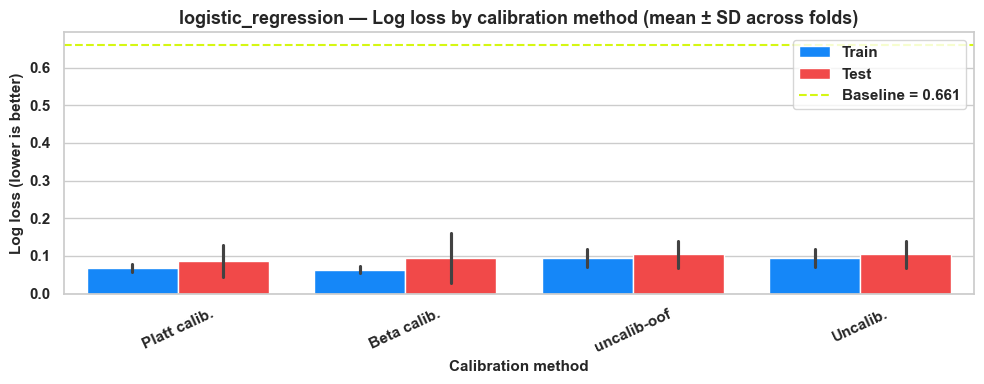

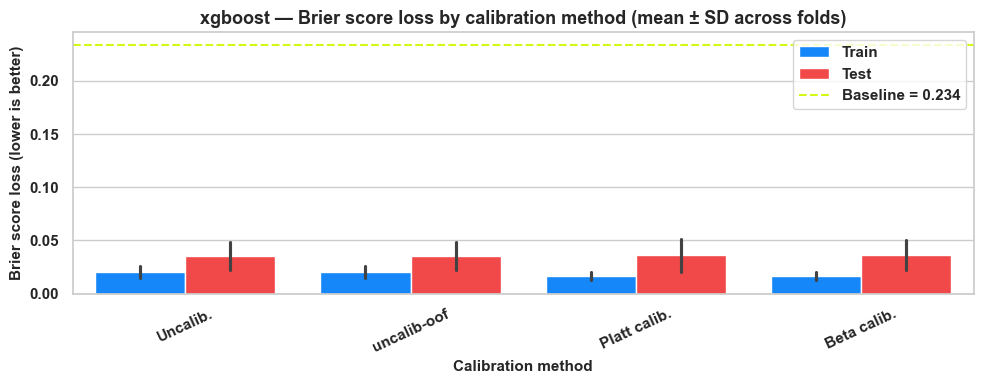

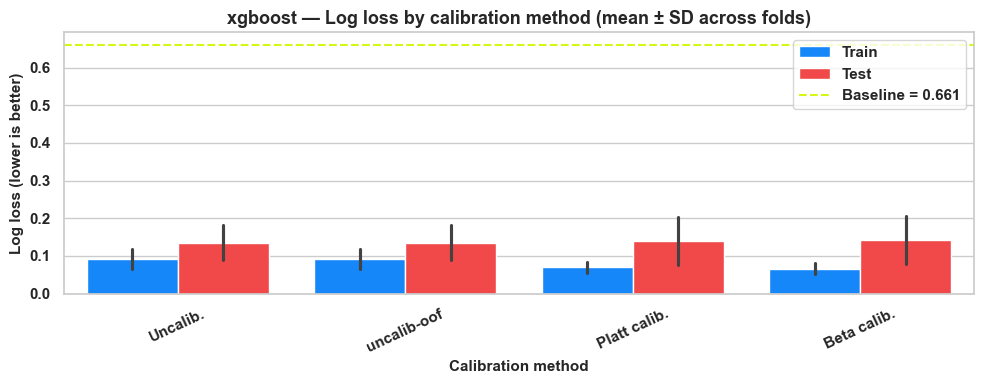

In [16]:

# Organize scores
eval_results = mtci.evaluate_nested_cv_results(
    all_results,
    metrics_to_compute=["average_precision", "roc_auc","brier_score_loss", "log_loss"],
    calibration_methods=["platt", "beta"],
)


alias = {
    "platt": "Platt calib.",
    "beta": "Beta calib.",
    "uncalib_oof": "uncalib-oof",
    "uncalibrated": "Uncalib.",
}

mtci.plot_brier_logloss_all_methods(
    eval_results,
    model_names=None,
    calibration_methods=["platt", "beta"],
    include_uncalibrated=True,
    include_uncalib_oof=True,
    sort_methods_by = "test",
    method_alias=alias,
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
     figsize=(10,4), legend_loc= "upper right", show_prevalence_baseline=True
)

### Compute pooled calibration **intercept (alpha) and slope (beta)** for each model and each calibration method using:

Models:   0%|          | 0/2 [00:00<?, ?it/s]

logistic_regression: methods:   0%|          | 0/3 [00:00<?, ?it/s]

xgboost: methods:   0%|          | 0/3 [00:00<?, ?it/s]


logistic_regression — Slope (β) (sorted by test closeness to ideal=1.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
Platt calib.                 1.0016 ± 0.0264            0.8976 ± 0.0419                    0.1024
Beta calib.                  1.0011 ± 0.0383            0.7714 ± 0.0623                    0.2286
uncalib                      2.0139 ± 0.0934            1.7777 ± 0.1371                    0.7777
------------------------------------------------------------------------------------------


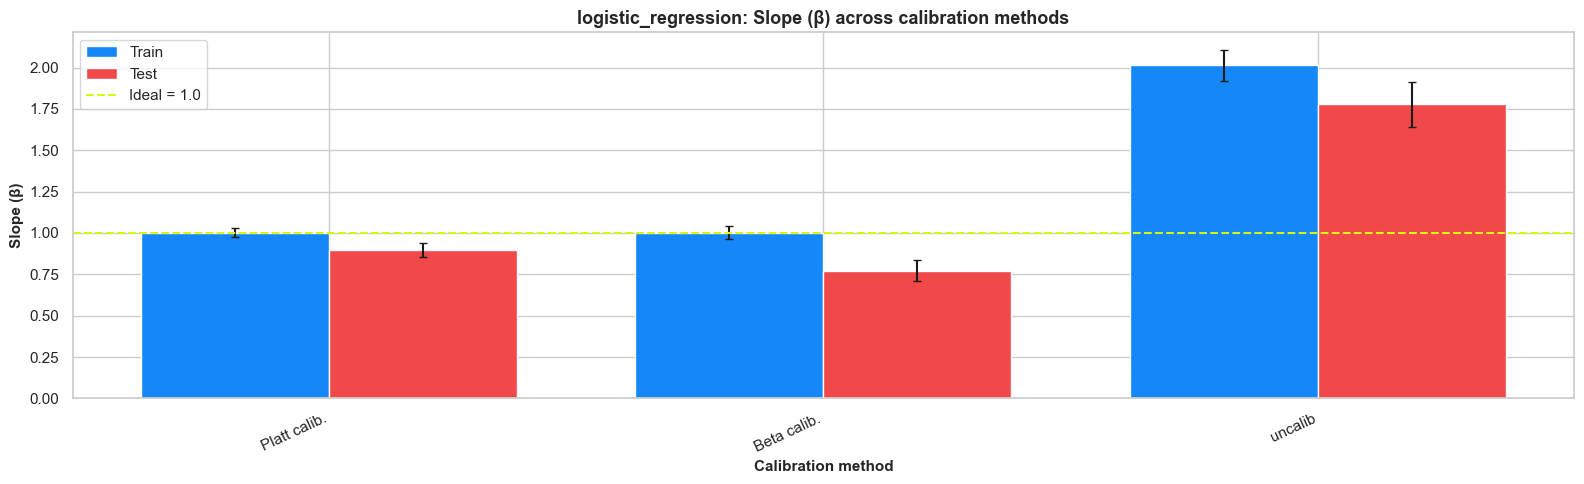


logistic_regression — Intercept (α) (sorted by test closeness to ideal=0.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
Platt calib.                 0.0076 ± 0.0884            0.0460 ± 0.1559                    0.0460
Beta calib.                  0.0081 ± 0.0833            0.1810 ± 0.1365                    0.1810
uncalib                      -0.5063 ± 0.0780           -0.4418 ± 0.1381                   0.4418
------------------------------------------------------------------------------------------


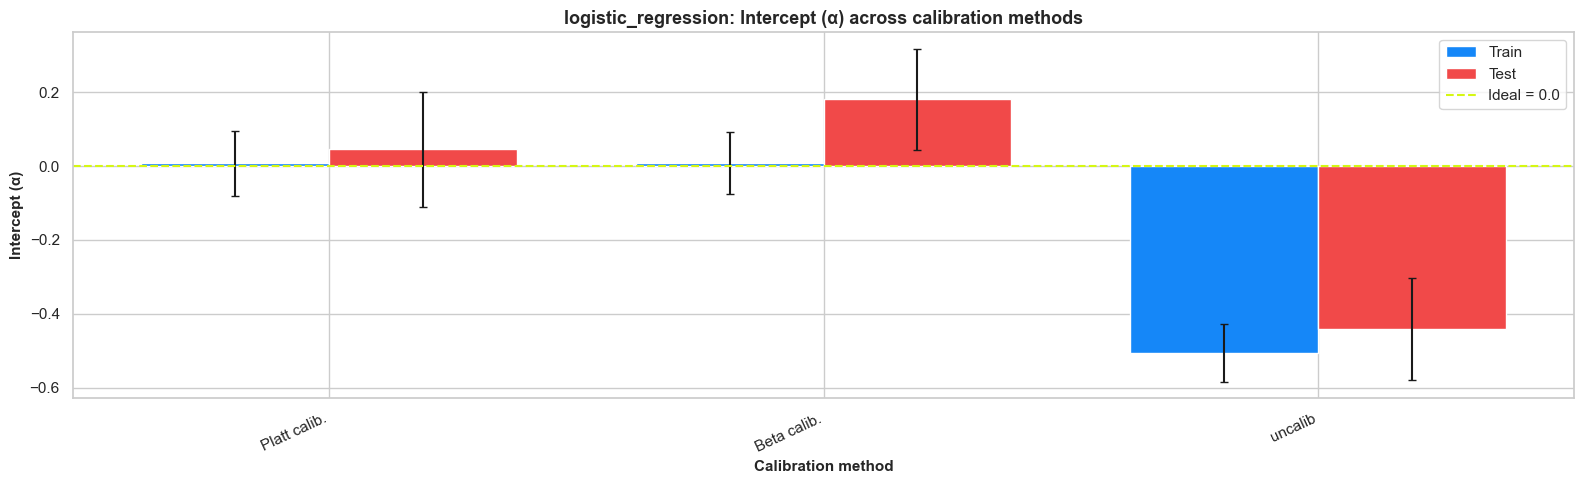


xgboost — Slope (β) (sorted by test closeness to ideal=1.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
Platt calib.                 1.0019 ± 0.0246            0.7991 ± 0.0296                    0.2009
uncalib                      1.6540 ± 0.0653            1.2656 ± 0.0698                    0.2656
Beta calib.                  1.0025 ± 0.0336            0.7073 ± 0.0397                    0.2927
------------------------------------------------------------------------------------------


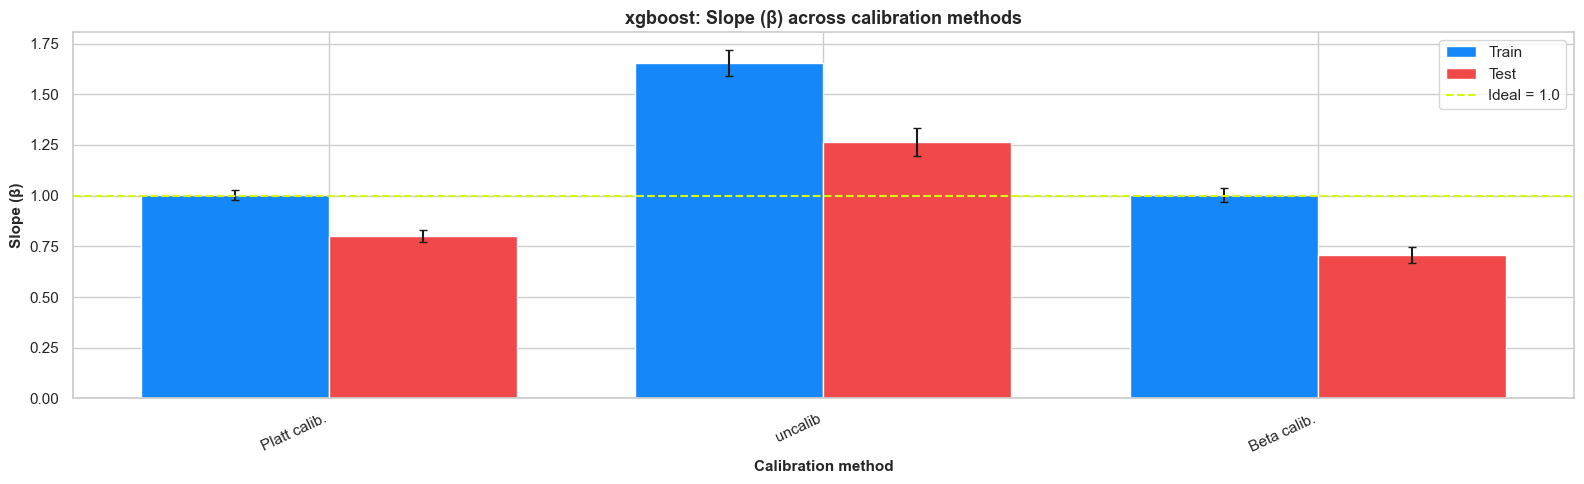


xgboost — Intercept (α) (sorted by test closeness to ideal=0.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
Platt calib.                 0.0035 ± 0.0877            0.1038 ± 0.1293                    0.1038
uncalib                      -0.2158 ± 0.0670           -0.1221 ± 0.1096                   0.1221
Beta calib.                  0.0021 ± 0.0971            0.2757 ± 0.1364                    0.2757
------------------------------------------------------------------------------------------


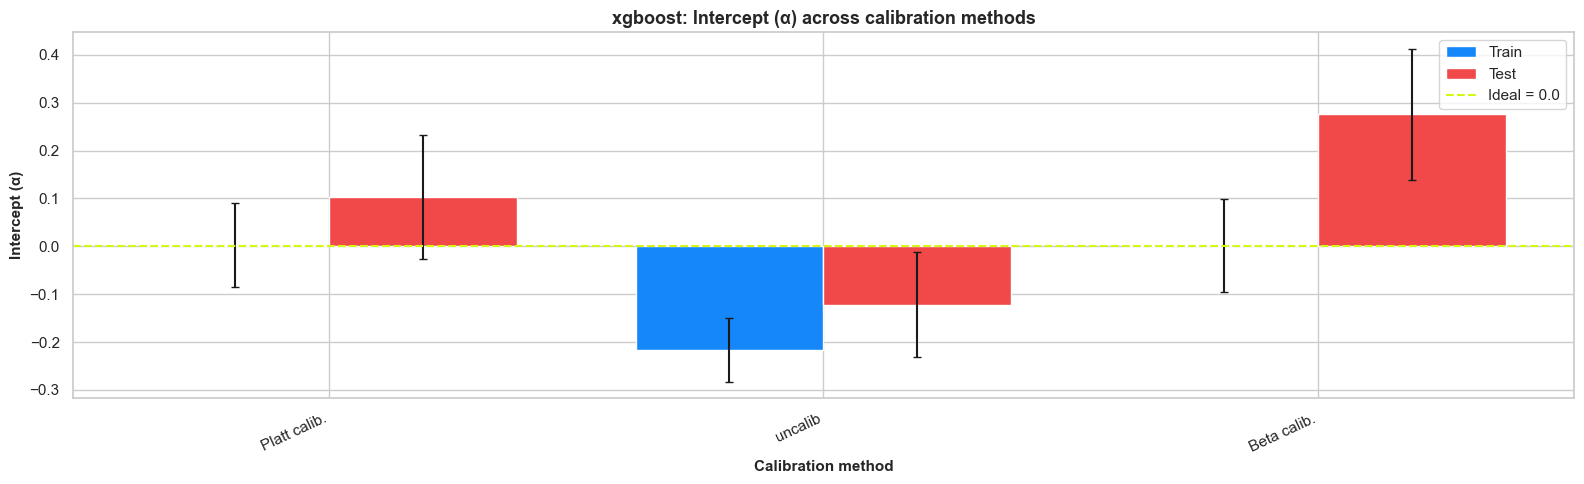

In [17]:
# -------------------------
# Example usage
# -------------------------
calibration_stats = mtci.pooled_bootstrap_calibration_stats_by_model(
    all_results,
    calibration_methods= ["platt", "beta"],  # or None to auto-discover
    n_boot=500, # bootstrap resamples used to estimate mean/std and 95% CI from pooled data
    seed=42,
    eps=1e-12,
)

# Short display names for plotting/table readability (method keys -> concise labels)
alias = {
    "platt": "Platt calib.",
    "beta": "Beta calib.",
    "uncalib_oof": "uncalib-oof",
    "uncalibrated": "Uncalib.",
}

mtci.plot_calibration_param(
    calibration_stats,
    model_name=None,
    methods=None,  # or ["platt", "beta"] + ["uncalibrated","uncalib_oof"]
    method_alias=alias,  # or ["platt", "beta"],+ ["uncalibrated","uncalib_oof"]
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    sort_by="test",
    figsize=(16, 5),
    font_size=11,
    legend_loc="best",
    show_ideal_line=True,
    ideal_line_color="#D5F713",
    ideal_line_lw=1.5,
    ideal_line_ls="--",
    print_table=True,
    table_decimals=4,
)




## Log loss and brier score: 

Using the user selected calibration method that showed best performance 

 - brier score
 - log loss
 - intercept (alpha)
 - slope (beta)

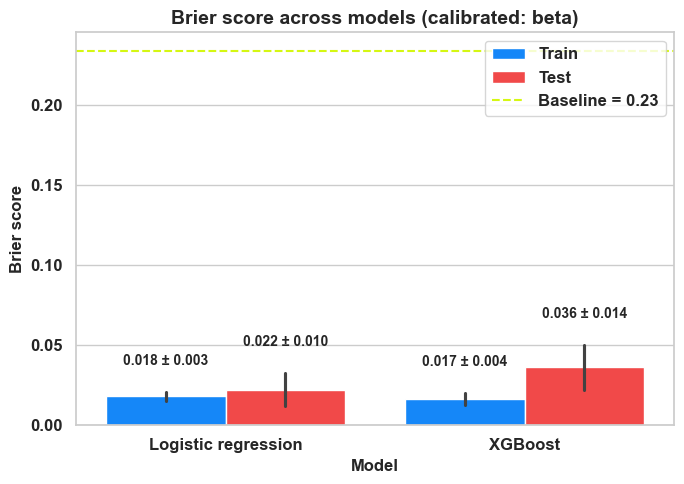

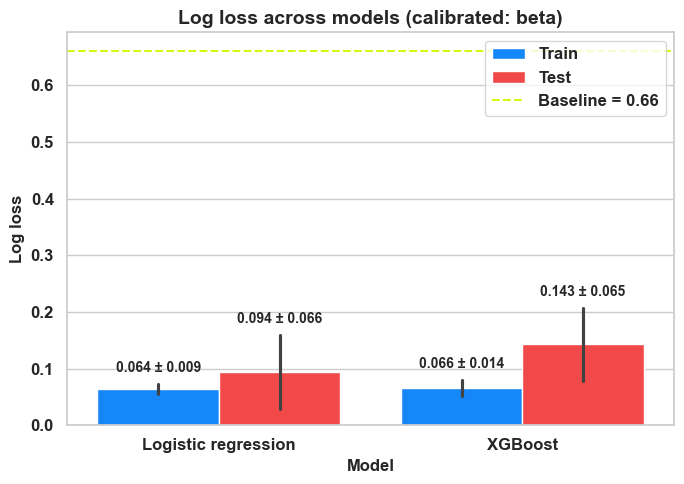

In [18]:

mtci.plot_brier_logloss(
    eval_results,
    model_names= None, # None= use all model with the same calibration
    calibration_method="beta",
    use_calibrated=True,
    include_uncalib_oof=False,
    method_alias={"logistic_regression": "Logistic regression", "xgboost": "XGBoost"},
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    figsize=(7,5), legend_loc= "upper right", show_prevalence_baseline=True,
    annotate_font_size = 10,
    #logloss_ylim=(0, 1)  
)




## AUROC and AUPRC barplots

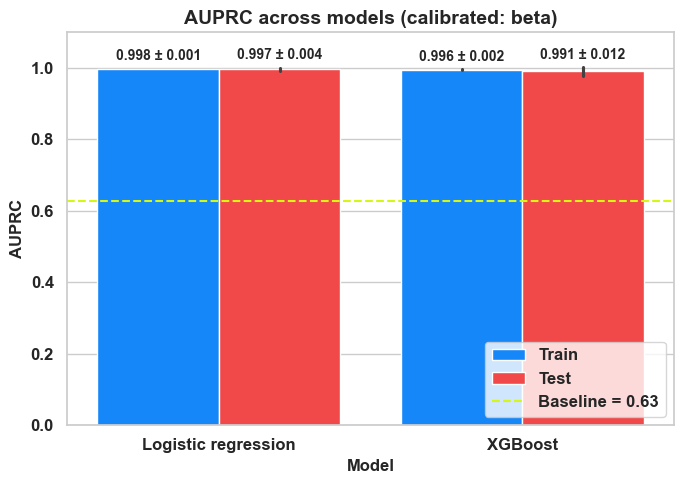

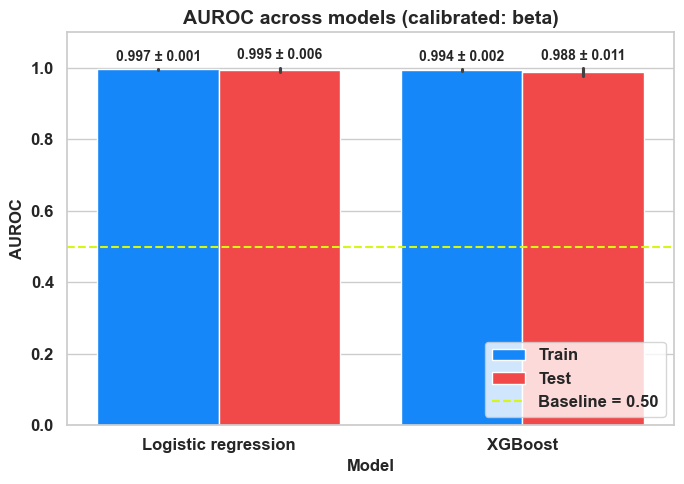

In [19]:
# # Uncalibrated plot if desired 
# mtci.plot_auprc_auroc(
#     eval_results,
#     model_names=None,
#     calibration_method=None,
#     use_calibrated=False,
#     include_uncalib_oof=True,
#     method_alias={"logistic_regression": "Logistic regression"},
#     split_palette={"Train": "#1587F8", "Test": "#F14949"},
#     figsize=(7,5), legend_loc= "upper right", show_prevalence_baseline=True,
#     annotate_font_size = 10
# )

mtci.plot_auprc_auroc(
    eval_results,
    model_names=None,
    calibration_method="beta",
    use_calibrated=True,
    include_uncalib_oof=False,
    method_alias={"logistic_regression": "Logistic regression", "xgboost": "XGBoost"},   # method_alias={"logistic_regression": "Logistic regression", "xgboost": "XGBoost"},
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    figsize=(7,5), legend_loc= "lower right", show_prevalence_baseline=True,
    annotate_font_size = 10,
    auprc_ylim = (0, 1.1),
    auroc_ylim =(0, 1.1) 
)

## Balanced accuracy

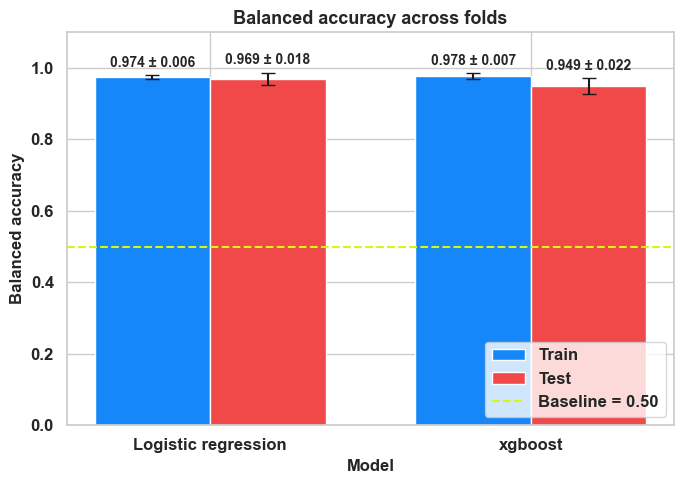

Per-model shared mean training-threshold summary:
  Logistic regression: shared threshold = 0.597 (from foldwise best-train thresholds: 0.597 ± 0.130)
  xgboost: shared threshold = 0.618 (from foldwise best-train thresholds: 0.618 ± 0.123)


In [20]:
mtci.barplot_balanced_accuracy(
    all_results,
    model_names=None,
    use_calibrated=True,
    calibration_method="beta",
    mode="mean_train_threshold",  # post-hoc best per split: ['mean_train_threshold','train_threshold', 'test_threshold', 'split_best']
    method_alias={"logistic_regression": "Logistic regression"},
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    show_baseline=True,
    baseline_color="#D5F713",
    figsize=(7,5),
    legend_loc="lower right",
    annotate_font_size = 10,
    ylim=(0,1.1),
    print_threshold_summary=True
)



## Calibration curve


>>> Generating calibration curve for model: logistic_regression


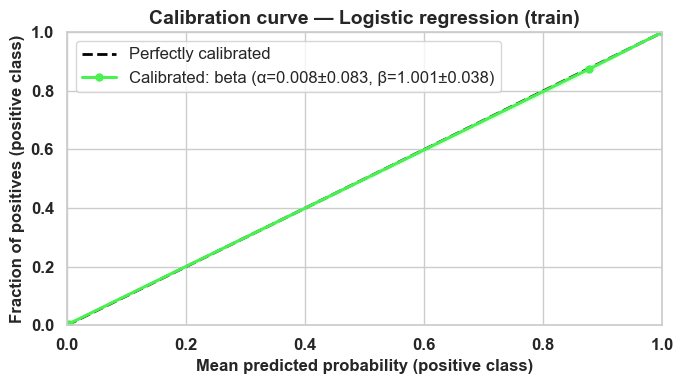

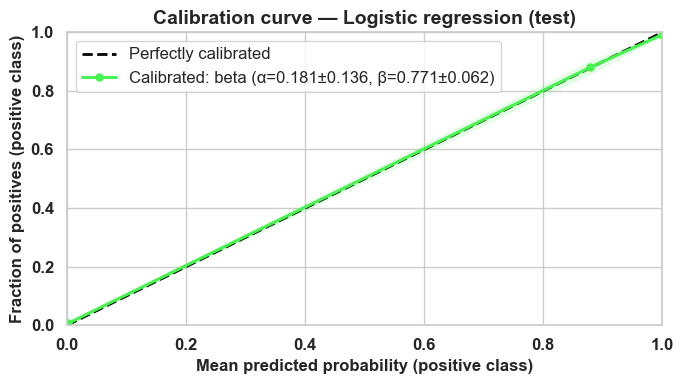

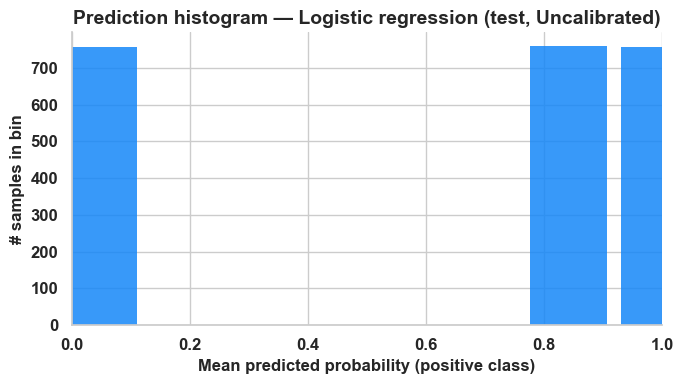

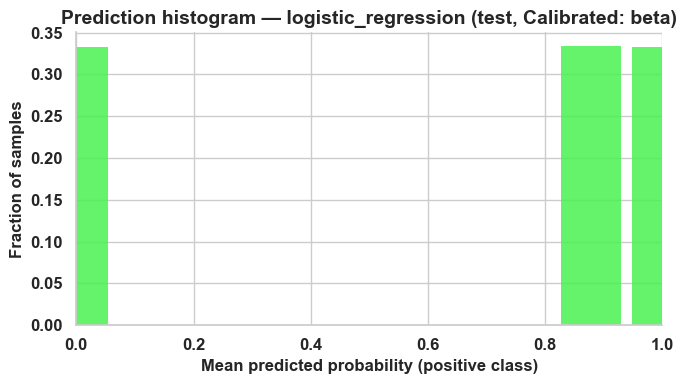


>>> DONE for model: logistic_regression

>>> Generating calibration curve for model: xgboost


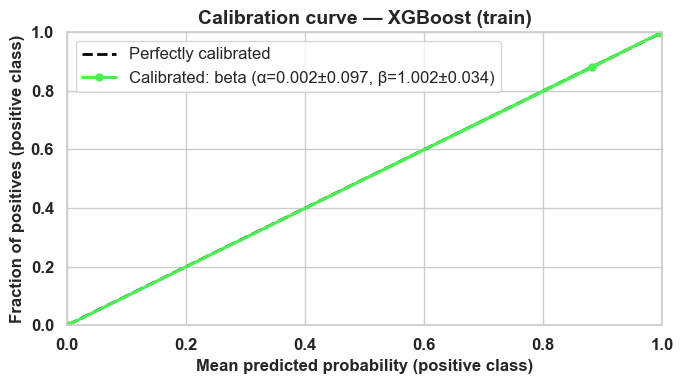

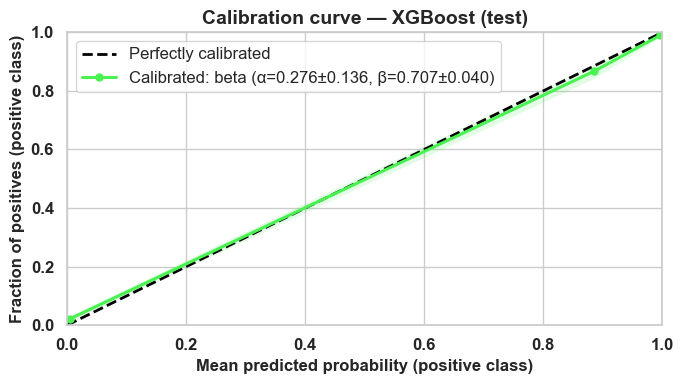

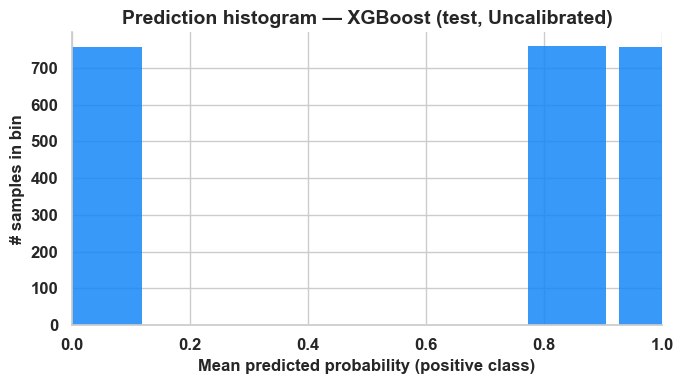

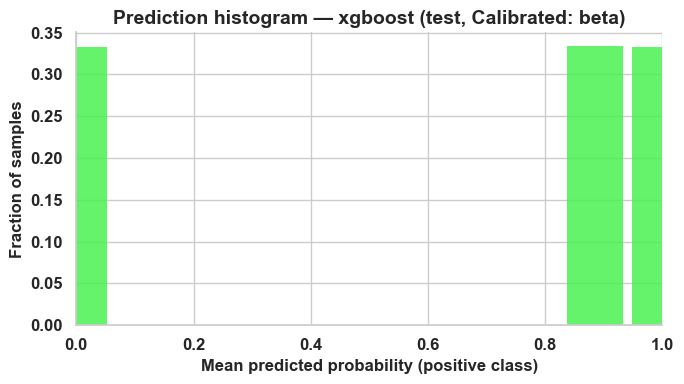


>>> DONE for model: xgboost


In [21]:
figsize=(7, 4)
calibration_methods=[ "beta"]
calibration_method_name = 'beta'

for model_name in ['logistic_regression', 'xgboost' ]: #'xgboost', 'logistic_regression'

    print(f"\n>>> Generating calibration curve for model: {model_name}")
    print('='*200)
    
    if model_name =="logistic_regression":
        method_alias={"logistic_regression": "Logistic regression"}

    elif model_name =="xgboost":
        method_alias={"xgboost": "XGBoost"}


    # model_name="logistic_regression"
    # figsize=(7, 4)

    calib_data = mtci.extract_calibration_data(
        all_results,
        model_name=model_name,
        calibration_methods=calibration_methods,
    )
    calib_data = mtci.calibration_data_prep(calib_data, n_bins=3, strategy="quantile")

    mtci.plot_calibration_curves(
        calib_data,
        model_name=model_name,
        methods=calibration_methods,
        include_uncalibrated=False,
        figsize=figsize,
        calibration_stats=calibration_stats,
        calibrated_color_map = {calibration_method_name: "#49F151"},
        show_alpha_beta=True,
        alpha_beta_decimals=3,
        method_alias=method_alias,
    )


    mtci.plot_calibration_histogram(
        calib_data,
        model_name=model_name,
        split="test",
        variant="uncalib",
        figsize=figsize,
        method_alias=method_alias,
        uncalib_color="#1587F8",
        calibrated_color_map={calibration_method_name: "#49F151"},
    )

    mtci.plot_calibration_histogram(
        calib_data,
        model_name=model_name,
        split="test",
        variant=calibration_method_name,
        normalize=True,
        figsize=figsize,
        calibrated_color_map={calibration_method_name: "#49F151"},
    )

   
    print(f"\n>>> DONE for model: {model_name}")

    

## Permutation feature importance (nested CV)

This section computes **permutation feature importance** for each model using the **outer test split** from nested cross-validation, then aggregates the results across folds for visualization.

### What permutation importance measures
Permutation importance estimates how much each feature contributes to model performance by:
1. Measuring the model’s baseline score on the test set (using the chosen `scoring` metric).
2. Shuffling one feature column at a time (breaking its relationship with the target).
3. Measuring how much the score drops after shuffling.
4. Repeating the shuffle multiple times (`n_repeats`) to get a stable distribution of importance values.

Larger importance values mean the model’s performance degrades more when that feature is permuted, suggesting the feature is more influential.

### Pipeline steps
We use a convenience pipeline that wraps two steps:

1. **Compute fold-level importances (outer test only)**  
   For each model and each outer fold, compute permutation importance using the already-fitted `final_model` and that fold’s `outer_test_idx`.

2. **Combine across folds**  
   Concatenate the importance repeats from all folds into one matrix per model:
   - `combined_importances[model_name]` has shape `(n_features, total_repeats)`  
   where `total_repeats = n_repeats × (# outer folds)`.

### Key parameters (what to tune)
- `scoring`: metric used to quantify the performance drop (e.g., `"roc_auc"` or `"average_precision"`).
- `n_repeats`: number of shuffles per feature per fold (higher = more stable, slower).
- `n_jobs`: parallelism (`-1` uses all CPU cores).
- `random_state`: controls shuffle reproducibility.

### Output used for plotting
The pipeline returns:
- `all_results` (mutated in-place with per-fold importance matrices)
- `combined_importances` (combined importance matrices used directly by the plotting function)

After this, we typically visualize the **top N features** by mean importance with error bars (std across repeats).


In [22]:
%%time

all_results, combined_importances, model_feature_names = mtci.run_permutation_importance_pipeline(
    all_results=all_results,                 # nested-CV results dict (mutated in-place to store fold-level permutation arrays)
    final_features=final_features,           # full dataset bundle (contains X/y arrays + feature_names for slicing)
    cfg=config,                              # config with per-model feature selection: feature_names OR n_features (mirrors training)
    scoring="roc_auc",                       # metric used to measure performance drop when a feature is permuted ("average_precision" also common)
    n_repeats=1000,                          # number of shuffles per feature per fold (higher = more stable, slower)
    random_state=42,                         # seed for reproducible shuffling
    n_jobs=-1,                               # parallelism for permutation_importance (-1 uses all cores)
)



Permutation importance pipeline:   0%|          | 0/2 [00:00<?, ?step/s]

logistic_regression: perm imp folds:   0%|          | 0/25 [00:00<?, ?it/s]

xgboost: perm imp folds:   0%|          | 0/25 [00:00<?, ?it/s]

CPU times: total: 34.2 s
Wall time: 54 s


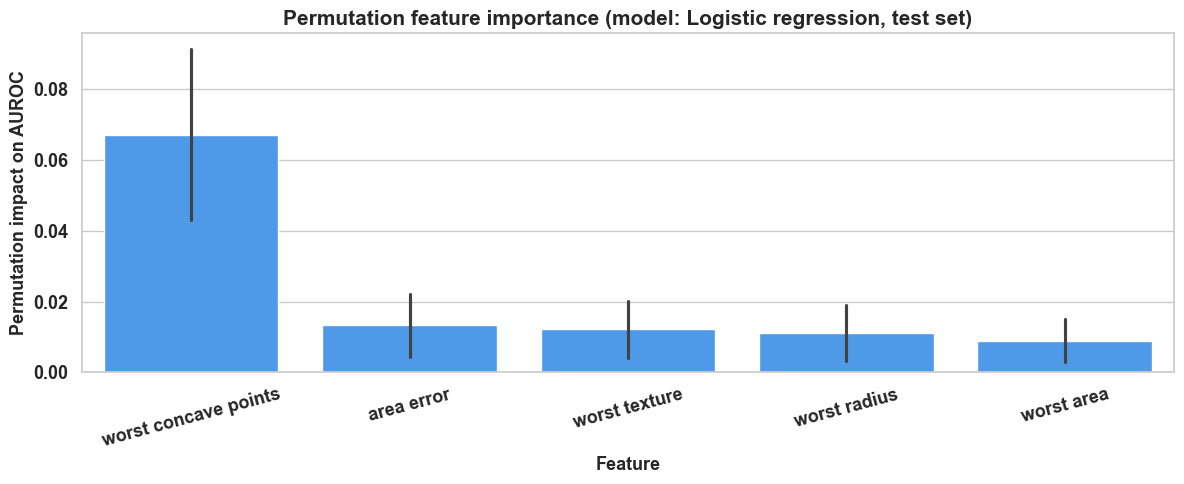

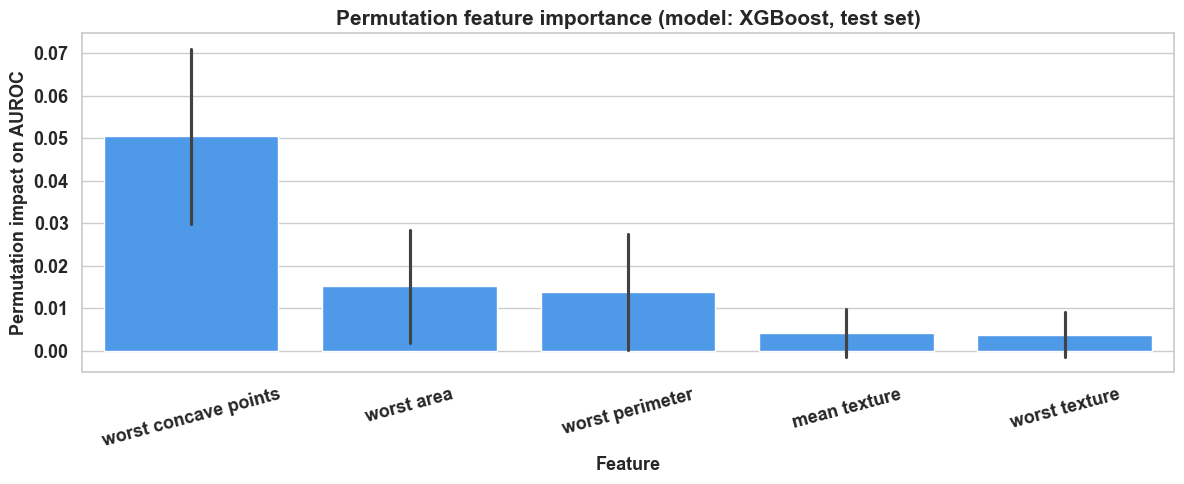

In [23]:

mtci.plot_permutation_importances_barplot(
    combined_importances=combined_importances,   # dict: model_name -> (n_features_model, total_repeats) matrix
    model_name=None,                             # None = plot ALL models; or set "xgboost", "logistic_regression", etc.
    feature_names=model_feature_names,           # dict: {model_name: [feature names used by that model]}
    top_n=12,                                    # show only the top 15 features by mean importance
    scoring="AUROC",                             # label only (computation used scoring="roc_auc" above)
    figsize=(12, 5),                              # figure size
    font_size=13,                                # base font size
    color="#4F99E9",                             # bar color
    x_tick_rotation=15,                          # rotate x labels for readability
    method_alias={                               # map internal model keys -> display names
        "logistic_regression": "Logistic regression",
    "xgboost": "XGBoost",
    },
)



## Partial dependence plots (PDPs) pipeline 

This section runs the full **Partial Dependence Plot (PDP)** workflow for the *EEG feature* dataset and then plots the **mean PDP ± 1 std** across outer folds.

### 1) Run the PDP pipeline
`run_pdp_pipeline(...)` combines three main steps into one call:

1. **Compute PDPs per outer fold** using the already-fitted `final_model` stored in `all_results`.
   - Handles low-cardinality/binary features by **padding PDP grids with NaNs** internally.
2. **Aggregate PDP points** across folds into a long-format DataFrame per model (`pdp_agg[model_name]`).
3. **Compute mean and std PDP curves** across folds on a common grid (`pdp_agg[f"{model_name}_mean_pdp"]`).

### 2) Plot mean PDP ± std
Finally, `plot_all_mean_pdp_with_std(...)` plots the **fold-averaged PDP curve** (mean) with a shaded band (± std) for every feature.

Key plotting controls:
- `model_name=None`: plot for all available models (or set a specific model, e.g. `"logistic_regression"`).



PDP pipeline:   0%|          | 0/3 [00:00<?, ?step/s]


=== Computing PDP for model: logistic_regression ===


logistic_regression folds:   0%|          | 0/25 [00:00<?, ?it/s]


=== Computing PDP for model: xgboost ===


xgboost folds:   0%|          | 0/25 [00:00<?, ?it/s]

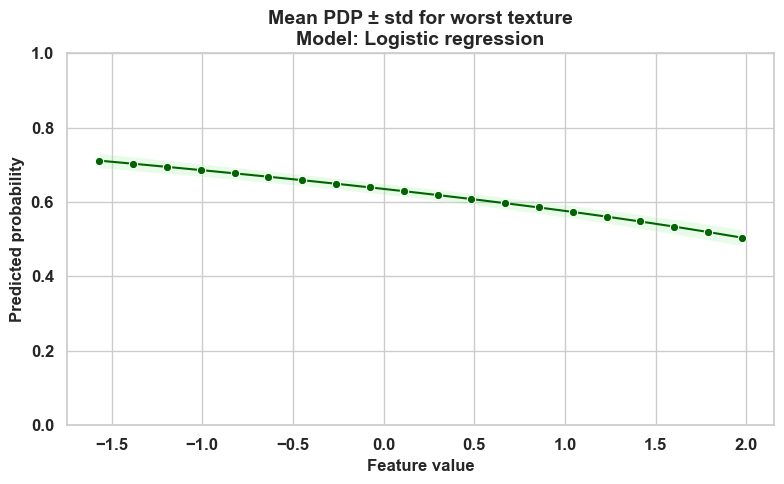

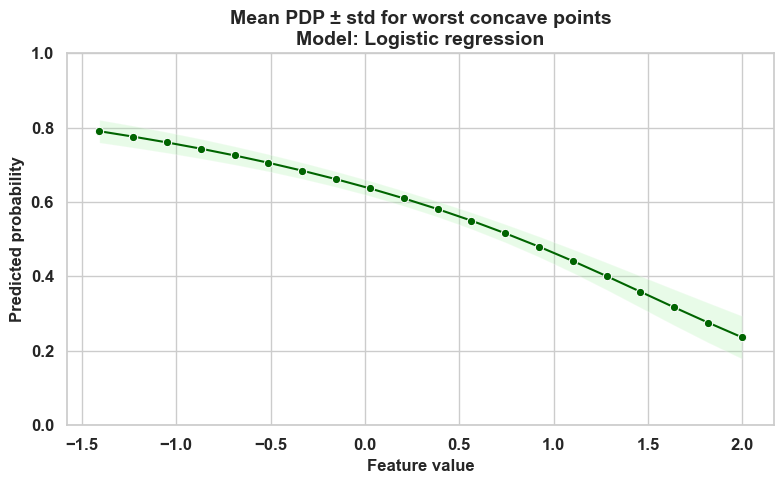

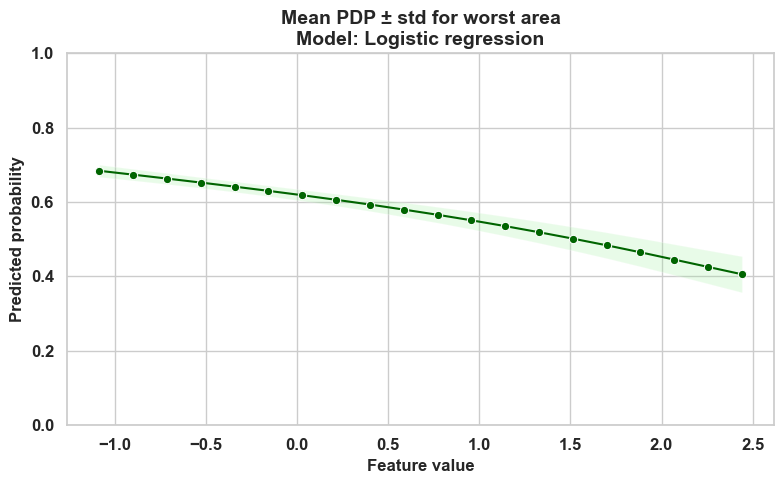

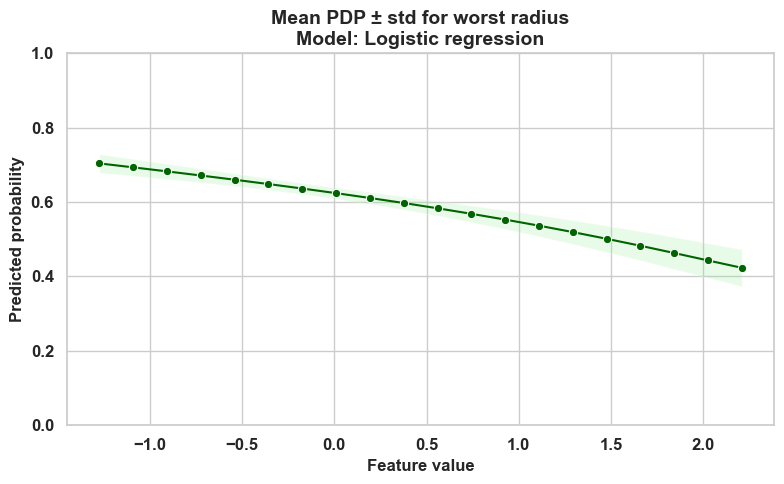

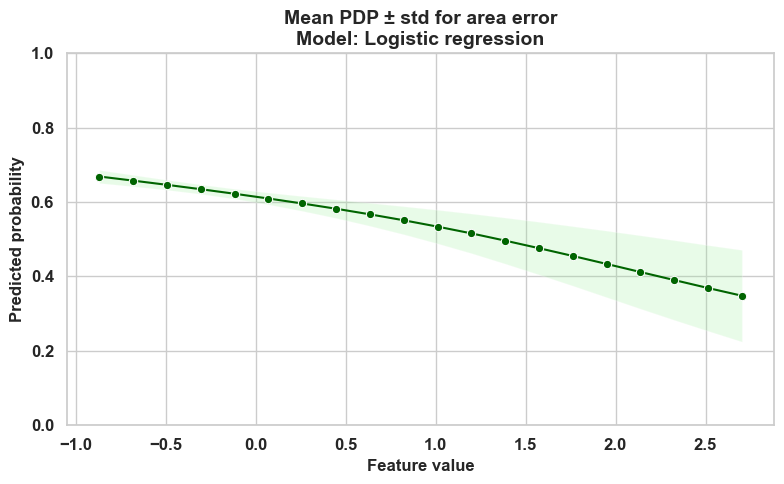

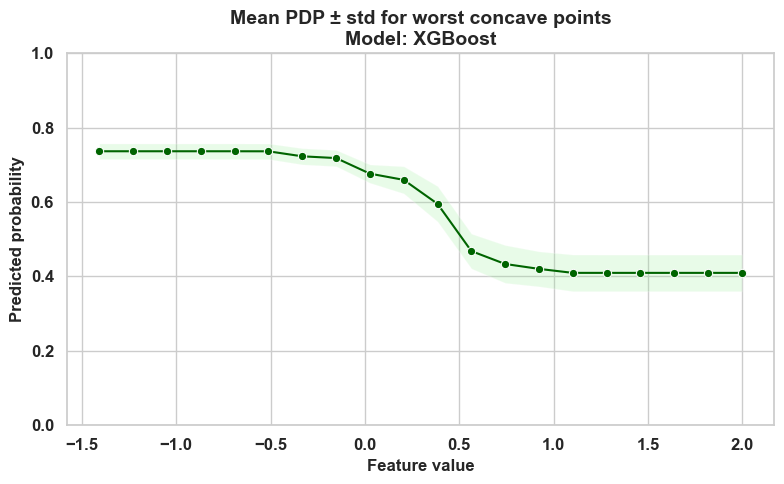

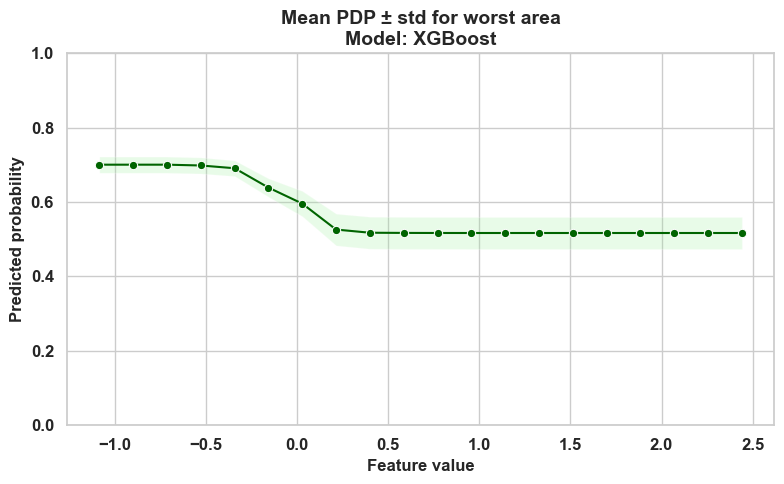

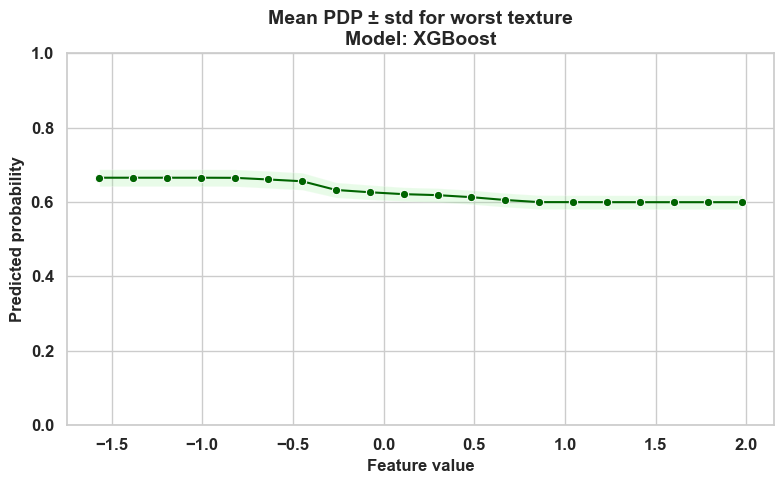

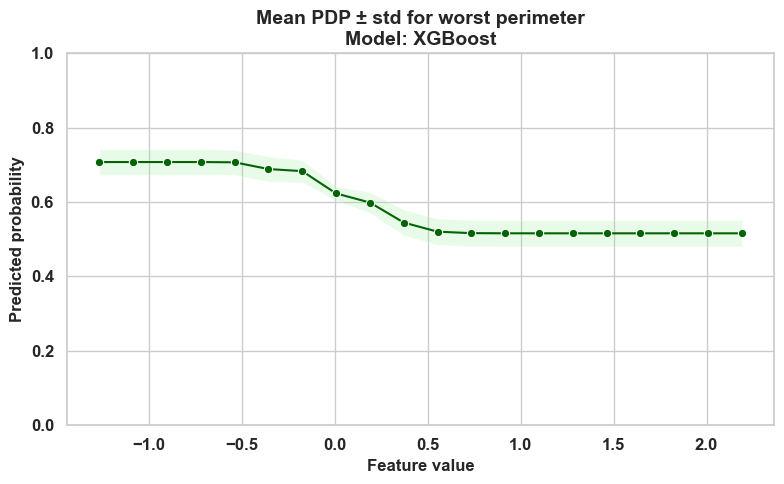

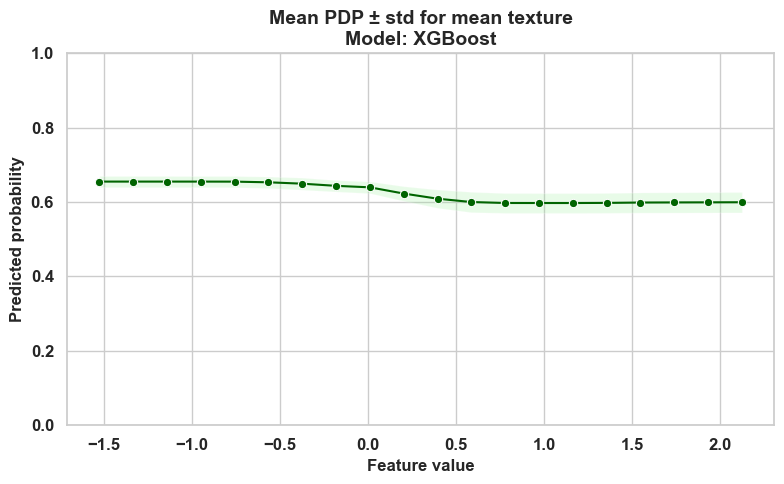

In [24]:
# ------------------------------------------------------------
# 1) Run PDP pipeline (compute per-fold PDPs -> aggregate -> mean/std -> optional raw x-axis)
# ------------------------------------------------------------
all_results, pdp_agg, model_feature_names = mtci.run_pdp_pipeline(
    all_results=all_results,                  # nested-CV outputs (dict of folds per model). Mutated in-place to store fold PDP arrays.
    final_features=final_features,            # full dataset (contains X/y arrays + feature_names for slicing)
    cfg=config,                               # config with per-model feature selection: feature_names OR n_features (mirrors training)

    # Which outer split to compute PDPs on
    data_source="test",          # "test" = PDP on outer-test sets only (most honest). "train" or "both" also allowed.

    # How sklearn builds the PDP x-grid per feature (before we later interpolate to a canonical grid)
    grid_resolution=100,         # requested # of grid points for continuous features (discrete features may produce fewer)
    percentiles=(0.0, 1.0),      # x-grid boundaries as percentiles of observed feature values (0..1 = full range)
    centered=False,              # if True, centers PDP curves (changes interpretation; shows deviations from baseline)

    # How we average curves across folds (canonical grid for mean/std)
    n_points=20,                 # number of points in canonical grid for continuous features (bigger => smoother mean curve)
    discrete_threshold=10,       # if a feature has <= this many unique values, treat as discrete (use unique values grid)
)



# ------------------------------------------------------------
# 2) Plot mean PDP ± std for every feature (one figure per feature per model)
# ------------------------------------------------------------
mtci.plot_all_mean_pdp_with_std(
    pdp_agg,                         # output dict from pipeline containing per-model mean/std tables

    # Which models to plot
    model_name=None,                 # None = plot ALL models in pdp_agg; or set "xgboost", "logistic_regression", etc.

    # Feature naming (important now that each model can have different feature sets)
    feature_names=model_feature_names,  # dict: {model_name: [feature names used by that model]} (like perm-importance barplot)

    # Plot formatting
    figsize=(8, 5),                  # size of each feature plot
    font_size=12,                    # base font size for labels/ticks/titles
    y_lim=(0.0, 1.0),                # optional fixed y-axis bounds (useful for probability outputs)
    line_color="darkgreen",          # PDP mean line color
    fill_color="lightgreen",         # color for the ±std shaded band
    sns_style="whitegrid",           # seaborn styling preset
    fill_alpha=0.2,                  # transparency for shaded band
    fill_edgecolor=None,             # edge outline for shaded band (None = no outline)

    # Optional: nicer names in titles
    method_alias={                   # map internal model keys -> display names used in plot titles
        "logistic_regression": "Logistic regression",
        "xgboost": "XGBoost",
    },
)


### Save final results

In [25]:


# Save output
mtci.save_all_results(output_dir='tutorial/run_1/breast_cancer', all_results=all_results, prefix='final_result', compress=True)
mtci.save_all_results(output_dir='tutorial/run_1/breast_cancer', all_results=bundle, prefix='final_bundle', compress=True)

# Load output
# all_results    = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)
# bundle         = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_bundle', compress=True)

✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_result.pkl.gz
✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_bundle.pkl.gz


WindowsPath('tutorial/run_1/breast_cancer')